In [2]:
import sys
sys.path.append('..')
from sqlalchemy import create_engine, text
import os

import geopandas as gpd
import pandas as pd
from geoalchemy2 import Geometry
import matplotlib.pyplot as plt

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

POSTGRES_UTEA['DATABASE'] = 'utea_precision'

In [3]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

def obtener_lotes_sin_planos():
    engine = obtener_engine()
    
    # Filtramos por lineas_creadas = True y segmentos_creados = False
    query = text("""
        SELECT * FROM siembra_surcado.data_lote 
            WHERE puntos_cargados IS TRUE
            AND lineas_creadas IS TRUE
            AND segmentos_creados IS TRUE
            AND desviacion_calculada IS TRUE
            AND velocidad_calculada IS TRUE
    """)
    
    try:
        with engine.connect() as conn:
            df = pd.read_sql(
                query, 
                conn, 
                params={
                    "lineas": True, 
                    "segmentos": False
                }
            )
        return df
    except Exception as e:
        print(f"Error al obtener lista de lotes son plano: {e}")
        return None
    
def get_segmentos_lote(id_lote):
    engine = obtener_engine()
    try:
        query = f"""
            SELECT * FROM siembra_surcado.segmentos_lineas where data_lote_id = {id_lote}
        """
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ No se pudo obtener segmentos de lote: {e}")
        return gpd.GeoDataFrame()
    return None

In [4]:
lista_lotes_sin_plano = obtener_lotes_sin_planos()
print(len(lista_lotes_sin_plano), 'lotes sin planos')

22 lotes sin planos


In [5]:
for index, row in lista_lotes_sin_plano.iterrows():
    print(row['id'])

8
1
5
6
18
19
21
14
2
4
15
16
20
17
13
12
22
23
11
9
10
7


In [6]:
segmentos_lote = get_segmentos_lote(2)

<Axes: >

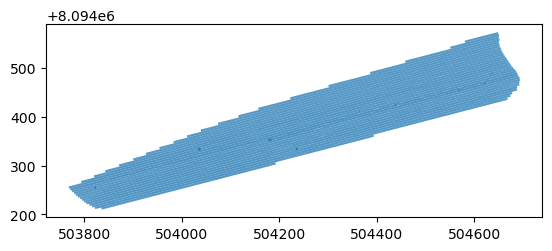

In [7]:
segmentos_lote.plot()

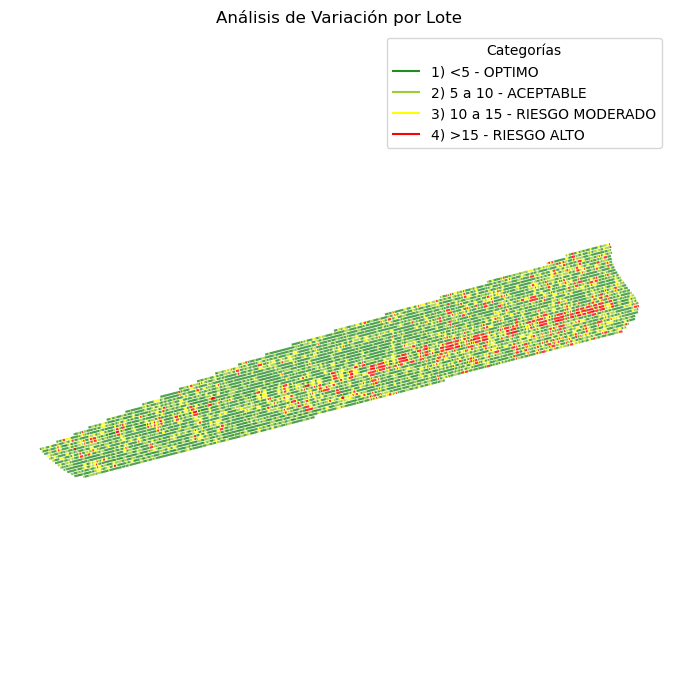

In [20]:
# 1. Configuración de colores (igual que antes)
colores_por_categoria = {
    '1) <5 - OPTIMO': '#228B22',
    '2) 5 a 10 - ACEPTABLE': '#9ACD32',
    '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
    '4) >15 - RIESGO ALTO': '#FF0000'
}

# 2. CALCULAR EL MARCO (Zoom automático)
# Obtenemos los límites del lote actual
minx, miny, maxx, maxy = segmentos_lote.total_bounds
centro_x = (minx + maxx) / 2
centro_y = (miny + maxy) / 2

# Definimos cuánto "espacio" queremos ver (en las unidades de tu mapa, ej. metros o grados)
# Ajusta este valor según el tamaño promedio de tus lotes
rango = max(maxx - minx, maxy - miny) * 1.1  # El 1.1 añade un 10% de margen 

# 3. GRAFICAR
fig, ax = plt.subplots(figsize=(8.5, 10)) # Tamaño físico de la imagen siempre 10x10 pulgadas

for categoria, data in segmentos_lote.groupby('categoria_variacion'):
    color = colores_por_categoria.get(categoria, 'black')
    data.plot(ax=ax, color=color, label=categoria, linewidth=1.5)

# 4. FORZAR EL TAMAÑO DEL PLANO
ax.set_xlim(centro_x - rango/2, centro_x + rango/2)
ax.set_ylim(centro_y - rango/2, centro_y + rango/2)

# Configuración final
ax.legend(title="Categorías", loc='upper right')
ax.set_aspect('equal') # CRUCIAL: Mantiene la proporción real para que no se deforme el lote
plt.title("Análisis de Variación por Lote")
plt.axis('off') # Opcional: quita coordenadas para un look más limpio

plt.show()

In [13]:
def generar_tabla(segmentos):
    """
    Recibe un GeoDataFrame o DataFrame con las columnas 'distance', 'swathwidth', 
    'id' y 'categoria_variacion' para generar una tabla formateada y con estilos.
    """
    
    # --- 1. CÁLCULOS MATEMÁTICOS ---
    # Calcular área por segmento (ha)
    segmentos['area_ha_calc'] = (segmentos['distance'] * segmentos['swathwidth']) / 10000

    # Agrupar por categoría
    tabla_resumen = segmentos.groupby('categoria_variacion').agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    # Calcular porcentaje (%)
    total_longitud = tabla_resumen['Longitud_m'].sum()
    tabla_resumen['%'] = (tabla_resumen['Longitud_m'] / total_longitud) * 100

    # Crear fila de Total
    fila_total = pd.DataFrame({
        'categoria_variacion': ['Total'],
        'Muestras': [tabla_resumen['Muestras'].sum()],
        'Longitud_m': [total_longitud],
        '%': [100.0],
        'Area': [tabla_resumen['Area'].sum()]
    })

    # Unir y Renombrar
    df_agrupado = pd.concat([tabla_resumen, fila_total], ignore_index=True)
    df_display = df_agrupado.rename(columns={'categoria_variacion': 'Categoria'})

    # --- 2. FORMATEO DE TEXTO ---
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    
    # Reordenar columnas finales
    df_display = df_display[['Categoria', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 3. APLICACIÓN DE ESTILOS (STYLER) ---
    colores_dict = {
        '1) <5 - OPTIMO': '#228B22',
        '2) 5 a 10 - ACEPTABLE': '#9ACD32',
        '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
        '4) >15 - RIESGO ALTO': '#FF0000'
    }

    df_con_estilo = df_display.style

    # A. Barra de datos en % (excluyendo la fila Total)
    idx_final = len(df_display) - 2
    df_con_estilo = df_con_estilo.bar(
        subset=pd.IndexSlice[:idx_final, '%'], 
        color='#90EE90', vmin=0, vmax=100, align='left'
    )

    # B. Formato de porcentaje visual
    df_con_estilo = df_con_estilo.format({'%': '{:.2f}%'})

    # C. Función interna para colores de categoría
    def estilo_categoria(val):
        if val in colores_dict:
            bg = colores_dict[val]
            text = 'black' if bg == '#FFFF00' else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; text-align: left;'
        return 'text-align: left;'

    df_con_estilo = df_con_estilo.map(estilo_categoria, subset=['Categoria'])

    # D. Bordes y alineación de columnas numéricas
    df_con_estilo = df_con_estilo.set_properties(**{'border': '1px solid black'})
    
    df_con_estilo = df_con_estilo.set_properties(
        subset=['Muestras', 'Longitud (m)', '%', 'Area'], 
        **{'text-align': 'right'}
    )

    # E. Negrita a la fila Total
    def negrita_total(row):
        return ['font-weight: bold' if row['Categoria'] == 'Total' else '' for _ in row]

    df_con_estilo = df_con_estilo.apply(negrita_total, axis=1)

    # F. Estilo de Cabecera
    df_con_estilo = df_con_estilo.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), 
                                     ('border', '1px solid black'), 
                                     ('background-color', '#ADD8E6'), 
                                     ('text-align', 'center')]}
    ])

    return df_con_estilo



In [14]:
mi_tabla = generar_tabla(segmentos_lote)
mi_tabla

,Categoria,Muestras,Longitud (m),%,Area
0,1) <5 - OPTIMO,10116,"11,991.43",52.10%,5.40
1,2) 5 a 10 - ACEPTABLE,5730,"6,779.03",29.46%,3.05
2,3) 10 a 15 - RIESGO MODERADO,2211,"2,619.90",11.38%,1.18
3,4) >15 - RIESGO ALTO,1383,"1,623.86",7.06%,0.73
4,Total,19440,"23,014.21",100.00%,10.36


In [40]:
import matplotlib.pyplot as plt
import dataframe_image as dfi
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
import os

def exportar_a_pdf(segmentos_lote, df_con_estilo, colores_dict, nombre_pdf="Reporte_Lote.pdf"):
    # --- 1. GUARDAR EL PLANO COMO IMAGEN TEMPORAL ---
    temp_plano = "temp_plano.png"
    fig, ax = plt.subplots(figsize=(8, 8))
    
    minx, miny, maxx, maxy = segmentos_lote.total_bounds
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    rango = max(maxx - minx, maxy - miny) * 1.1

    for cat, data in segmentos_lote.groupby('categoria_variacion'):
        ax = data.plot(ax=ax, color=colores_dict.get(cat, 'black'), linewidth=1.5)

    ax.set_xlim(cx - rango/2, cx + rango/2)
    ax.set_ylim(cy - rango/2, cy + rango/2)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.savefig(temp_plano, dpi=150, bbox_inches='tight')
    plt.close()

    # --- 2. GUARDAR EL STYLER COMO IMAGEN TEMPORAL ---
    temp_tabla = "temp_tabla.png"
    # Exportamos el objeto Styler a imagen (mantiene colores y barra verde)
    dfi.export(df_con_estilo, temp_tabla)

    # --- 3. CREAR EL PDF (ReportLab) ---
    c = canvas.Canvas(nombre_pdf, pagesize=letter)
    ancho_p, alto_p = letter # 612 x 792 puntos

    # Título del Reporte
    c.setFont("Helvetica-Bold", 16)
    c.drawCentredString(ancho_p/2, alto_p - 50, "REPORTE DE VARIACIÓN POR LOTE")

    # Insertar el Plano (Centrado arriba)
    #drawImage(ruta, x, y, ancho, alto)
    c.drawImage(temp_plano, 0.5*inch, 3.5*inch, width=7.5*inch, preserveAspectRatio=True)

    # Insertar la Tabla (Abajo a la derecha o centrada)
    # Calculamos posición para que quede abajo
    c.drawImage(temp_tabla, 4.0*inch, 1.0*inch, width=3.5*inch, preserveAspectRatio=True)

    # Información extra (opcional)
    c.setFont("Helvetica", 10)
    c.drawString(0.5*inch, 0.5*inch, "Generado automáticamente por Sistema de Monitoreo.")

    # Guardar PDF
    c.showPage()
    c.save()

    # --- 4. LIMPIEZA ---
    os.remove(temp_plano)
    os.remove(temp_tabla)
    print(f"PDF generado con éxito: {nombre_pdf}")

# USO:
# exportar_a_pdf(segmentos_lote, df_con_estilo, colores_dict)

In [107]:
# USO:
exportar_a_pdf(df_con_estilo)

PDF generado con éxito (Horizontal): Reporte_Lote.pdf


In [106]:
def exportar_a_pdf(df_con_estilo, nombre_pdf="Reporte_Lote.pdf"):
    # --- 1. GUARDAR EL STYLER COMO IMAGEN TEMPORAL ---
    temp_tabla = "temp_tabla.png"
    dfi.export(df_con_estilo, temp_tabla)

    # --- 2. CREAR EL PDF EN ORIENTACIÓN HORIZONTAL ---
    # Usamos landscape(letter) para rotar la hoja
    c = canvas.Canvas(nombre_pdf, pagesize=landscape(letter))
    ancho_p, alto_p = landscape(letter) # Ahora ancho_p es ~792 y alto_p es ~612

    # Título del Reporte (Centrado en el nuevo ancho)
    c.setFont("Helvetica-Bold", 16)
    c.drawCentredString(ancho_p/2, alto_p - 50, "REPORTE DE VARIACIÓN POR LOTE")

    # --- INSERTAR LA TABLA EN LA ESQUINA INFERIOR IZQUIERDA ---
    # Al ser horizontal, tienes más espacio a lo ancho si deseas aumentar el 'width'
    c.drawImage(temp_tabla, 1*28.35, -0.5*28.35, width=5.0*inch, preserveAspectRatio=True)

    # Pie de página
    #c.setFont("Helvetica", 8)
    #c.drawString(0.5*inch, 0.25*inch, "Generado automáticamente por Sistema de Monitoreo.")

    # Guardar PDF
    c.showPage()
    c.save()

    # --- 3. LIMPIEZA ---
    if os.path.exists(temp_tabla): 
        os.remove(temp_tabla)
        
    print(f"PDF generado con éxito (Horizontal): {nombre_pdf}")

In [67]:
def exportar_a_pdf(segmentos_lote, df_con_estilo, colores_dict, nombre_pdf="Reporte_Lote.pdf"):
    # --- 1. GUARDAR EL PLANO COMO IMAGEN TEMPORAL ---
    temp_plano = "temp_plano.png"
    fig, ax = plt.subplots(figsize=(8, 8))
    
    minx, miny, maxx, maxy = segmentos_lote.total_bounds
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    rango = max(maxx - minx, maxy - miny) * 1.1

    for cat, data in segmentos_lote.groupby('categoria_variacion'):
        ax = data.plot(ax=ax, color=colores_dict.get(cat, 'black'), linewidth=1.5)

    ax.set_xlim(cx - rango/2, cx + rango/2)
    ax.set_ylim(cy - rango/2, cy + rango/2)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.savefig(temp_plano, dpi=150, bbox_inches='tight')
    plt.close()

    # --- 2. GUARDAR EL STYLER COMO IMAGEN TEMPORAL ---
    temp_tabla = "temp_tabla.png"
    dfi.export(df_con_estilo, temp_tabla)

    # --- 3. CREAR EL PDF (ReportLab) ---
    c = canvas.Canvas(nombre_pdf, pagesize=letter)
    ancho_p, alto_p = letter 

    # Título del Reporte
    c.setFont("Helvetica-Bold", 16)
    c.drawCentredString(ancho_p/2, alto_p - 50, "REPORTE DE VARIACIÓN POR LOTE")

    # Insertar el Plano (Centrado en la parte superior)
    c.drawImage(temp_plano, 0.5*inch, 4.0*inch, width=7.5*inch, preserveAspectRatio=True)

    # --- CAMBIO AQUÍ: Insertar la Tabla en la esquina inferior izquierda ---
    # x=0.5*inch (margen izquierdo), y=0.5*inch (margen inferior)
    c.drawImage(temp_tabla, 0.5*inch, 0.5*inch, width=3.5*inch, preserveAspectRatio=True)

    # Información de pie de página (ajustada para no solaparse)
    c.setFont("Helvetica", 8)
    c.drawString(0.5*inch, 0.25*inch, "Generado automáticamente por Sistema de Monitoreo.")

    # Guardar PDF
    c.showPage()
    c.save()

    # --- 4. LIMPIEZA ---
    if os.path.exists(temp_plano): os.remove(temp_plano)
    if os.path.exists(temp_tabla): os.remove(temp_tabla)
    print(f"PDF generado con éxito: {nombre_pdf}")